In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import networkx 
import bokeh
from bokeh.io import output_notebook, show, save
from bokeh.models import Range1d, Circle, ColumnDataSource, MultiLine, EdgesAndLinkedNodes, NodesAndLinkedEdges
from bokeh.plotting import figure
from bokeh.plotting import from_networkx
from bokeh.palettes import Blues8, Reds8, Purples8, Oranges8, Viridis8, Spectral8
from bokeh.transform import linear_cmap
from networkx.algorithms import community
import matplotlib.pyplot as plt
from collections import defaultdict
from heapq import nlargest

In [2]:
train = pd.read_csv("/kaggle/input/icr-identify-age-related-conditions/train.csv")
greeks = pd.read_csv("/kaggle/input/icr-identify-age-related-conditions/greeks.csv")
test = pd.read_csv("/kaggle/input/icr-identify-age-related-conditions/test.csv")

In [3]:
train.head()

,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class
0,000ff2bfdfe9,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,...,7.298162,1.73855,0.094822,11.339138,72.611063,2003.810319,22.136229,69.834944,0.120343,1
1,007255e47698,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,...,0.173229,0.49706,0.568932,9.292698,72.611063,27981.562750,29.135430,32.131996,21.978000,0
2,013f2bd269f5,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,...,7.709560,0.97556,1.198821,37.077772,88.609437,13676.957810,28.022851,35.192676,0.196941,0
3,043ac50845d5,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,...,6.122162,0.49706,0.284466,18.529584,82.416803,2094.262452,39.948656,90.493248,0.155829,0
4,044fb8a146ec,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,...,8.153058,48.50134,0.121914,16.408728,146.109943,8524.370502,45.381316,36.262628,0.096614,1


In [4]:
greeks = greeks.drop("Epsilon",axis=1)

In [5]:
train2 = pd.merge(train,greeks,left_on="Id",right_on="Id",how="outer")

In [6]:
train_ids = list(train['Id'])
y_train = train['Class']
train = train.set_index("Id")

In [7]:
train2_ids = list(train2['Id'])
y_train2 = train['Class']
train2 = train2.set_index("Id")

In [8]:
train = pd.get_dummies(train)
train2 = pd.get_dummies(train2)

# Heatmap

In [9]:
# Correlation Heatmap

train_corr = train.corr()
train2_corr = train2.corr()

fig = px.imshow(train2_corr, text_auto=True)
fig.show()

# Bokeh Network Visualization

According to the heatmap there are many features that are correlated with one another. A network graph will be constructed to try and show these clusters of features so that we can get a better sense of the relationship between features. For this network graph the nodes will represent the features and the edges will represent a correlation with an absolute value > 0.5

In [10]:
"""
Creating a new DataFrame in the structure needed for a network graph

Have to convert column string names into integers due to an error the Bokeh
package gives when building the visualization
  
"""


index = list(train2_corr.index)
cols = list(train2_corr.columns)
d = {}
x = 0
for i in range(len(cols)):
    d[cols[i]] = x
    x+=1

source,target,correlation = [],[],[]

for i in range(len(cols)):
    for j in range(len(index)):
        if cols[i] == index[j]:
            continue
        else:
            source.append(d[cols[i]])
            target.append(d[index[j]])
            correlation.append(train2_corr[cols[i]][j])

network_df = pd.DataFrame()
network_df['Source'] = source
network_df['Target'] = target
network_df['Correlation'] = correlation

network_df = network_df[abs(network_df['Correlation']) > 0.5]

In [11]:
# Bokeh Network Visualization
output_notebook()

G = networkx.from_pandas_edgelist(network_df, 'Source', 'Target', 'Correlation')
degrees = dict(networkx.degree(G))
networkx.set_node_attributes(G, name='degree', values=degrees)

number_to_adjust_by = 5
adjusted_node_size = dict([(node, degree+number_to_adjust_by) for node, degree in networkx.degree(G)])
networkx.set_node_attributes(G, name='adjusted_node_size', values=adjusted_node_size)

node_highlight_color = 'white'
edge_highlight_color = 'black'

size_by_this_attribute =   'adjusted_node_size'
color_by_this_attribute = 'skyblue'

color_palette = Blues8

title = 'Feature Linkage Graph'

HOVER_TOOLTIPS = [
       ("Feature ID", "@index"),
        ("# of Highly Correlated Features", "@degree")
]

plot = figure(tooltips = HOVER_TOOLTIPS,
              tools="pan,wheel_zoom,save,reset", active_scroll='wheel_zoom',
            x_range=Range1d(-10.1, 10.1), y_range=Range1d(-10.1, 10.1), title=title)

network_graph = from_networkx(G, networkx.spring_layout, scale=10, center=(0, 0))

network_graph.node_renderer.glyph = Circle(size=size_by_this_attribute, fill_color=color_by_this_attribute)

network_graph.node_renderer.hover_glyph = Circle(size=size_by_this_attribute, fill_color=node_highlight_color, line_width=2)
network_graph.node_renderer.selection_glyph = Circle(size=size_by_this_attribute, fill_color=node_highlight_color, line_width=2)

network_graph.edge_renderer.glyph = MultiLine(line_alpha=0.5, line_width=1)

network_graph.edge_renderer.selection_glyph = MultiLine(line_color=edge_highlight_color, line_width=2)
network_graph.edge_renderer.hover_glyph = MultiLine(line_color=edge_highlight_color, line_width=2)

network_graph.selection_policy = NodesAndLinkedEdges()
network_graph.inspection_policy = NodesAndLinkedEdges()

plot.renderers.append(network_graph)

show(plot)

Loading BokehJS ...

In [12]:
# Feature ID Map
d

{'AB': 0,
 'AF': 1,
 'AH': 2,
 'AM': 3,
 'AR': 4,
 'AX': 5,
 'AY': 6,
 'AZ': 7,
 'BC': 8,
 'BD ': 9,
 'BN': 10,
 'BP': 11,
 'BQ': 12,
 'BR': 13,
 'BZ': 14,
 'CB': 15,
 'CC': 16,
 'CD ': 17,
 'CF': 18,
 'CH': 19,
 'CL': 20,
 'CR': 21,
 'CS': 22,
 'CU': 23,
 'CW ': 24,
 'DA': 25,
 'DE': 26,
 'DF': 27,
 'DH': 28,
 'DI': 29,
 'DL': 30,
 'DN': 31,
 'DU': 32,
 'DV': 33,
 'DY': 34,
 'EB': 35,
 'EE': 36,
 'EG': 37,
 'EH': 38,
 'EL': 39,
 'EP': 40,
 'EU': 41,
 'FC': 42,
 'FD ': 43,
 'FE': 44,
 'FI': 45,
 'FL': 46,
 'FR': 47,
 'FS': 48,
 'GB': 49,
 'GE': 50,
 'GF': 51,
 'GH': 52,
 'GI': 53,
 'GL': 54,
 'Class': 55,
 'EJ_A': 56,
 'EJ_B': 57,
 'Alpha_A': 58,
 'Alpha_B': 59,
 'Alpha_D': 60,
 'Alpha_G': 61,
 'Beta_A': 62,
 'Beta_B': 63,
 'Beta_C': 64,
 'Gamma_A': 65,
 'Gamma_B': 66,
 'Gamma_E': 67,
 'Gamma_F': 68,
 'Gamma_G': 69,
 'Gamma_H': 70,
 'Gamma_M': 71,
 'Gamma_N': 72,
 'Delta_A': 73,
 'Delta_B': 74,
 'Delta_C': 75,
 'Delta_D': 76}

In [13]:

#Features found in each cluster:

#19, 22, 35, 20, 4, 40, 33, 2  --> each of these features are highly correlated with each other
#CH, CS, EB, CL, AR, EP, DV, AH

#14, 8, 18, 9, 6, 16
#BZ, BC, CF, BD, AY, CC

#67, 60, 68
#Gamma_E, Alpha_D, Gamma_F

#61, 66, 65
#Alpha_G, Gamma_B, Gamma_A

#72, 71, 59,58,55,70  --> 55 is the Class Variable, interesting to note its highly correlated with 
#some of the features from greeks.csv
#Gamma_N, Gamma_M, Alpha_B, Alpha_A, Class, Gamma_H

#63, 64, 73, 74, 75
#Beta_B, Beta_C, Delta_A, Delta_B, Delta_C

#57,56,54
#EJ_B, EJ_A, GL

#0, 3
#AB, AM


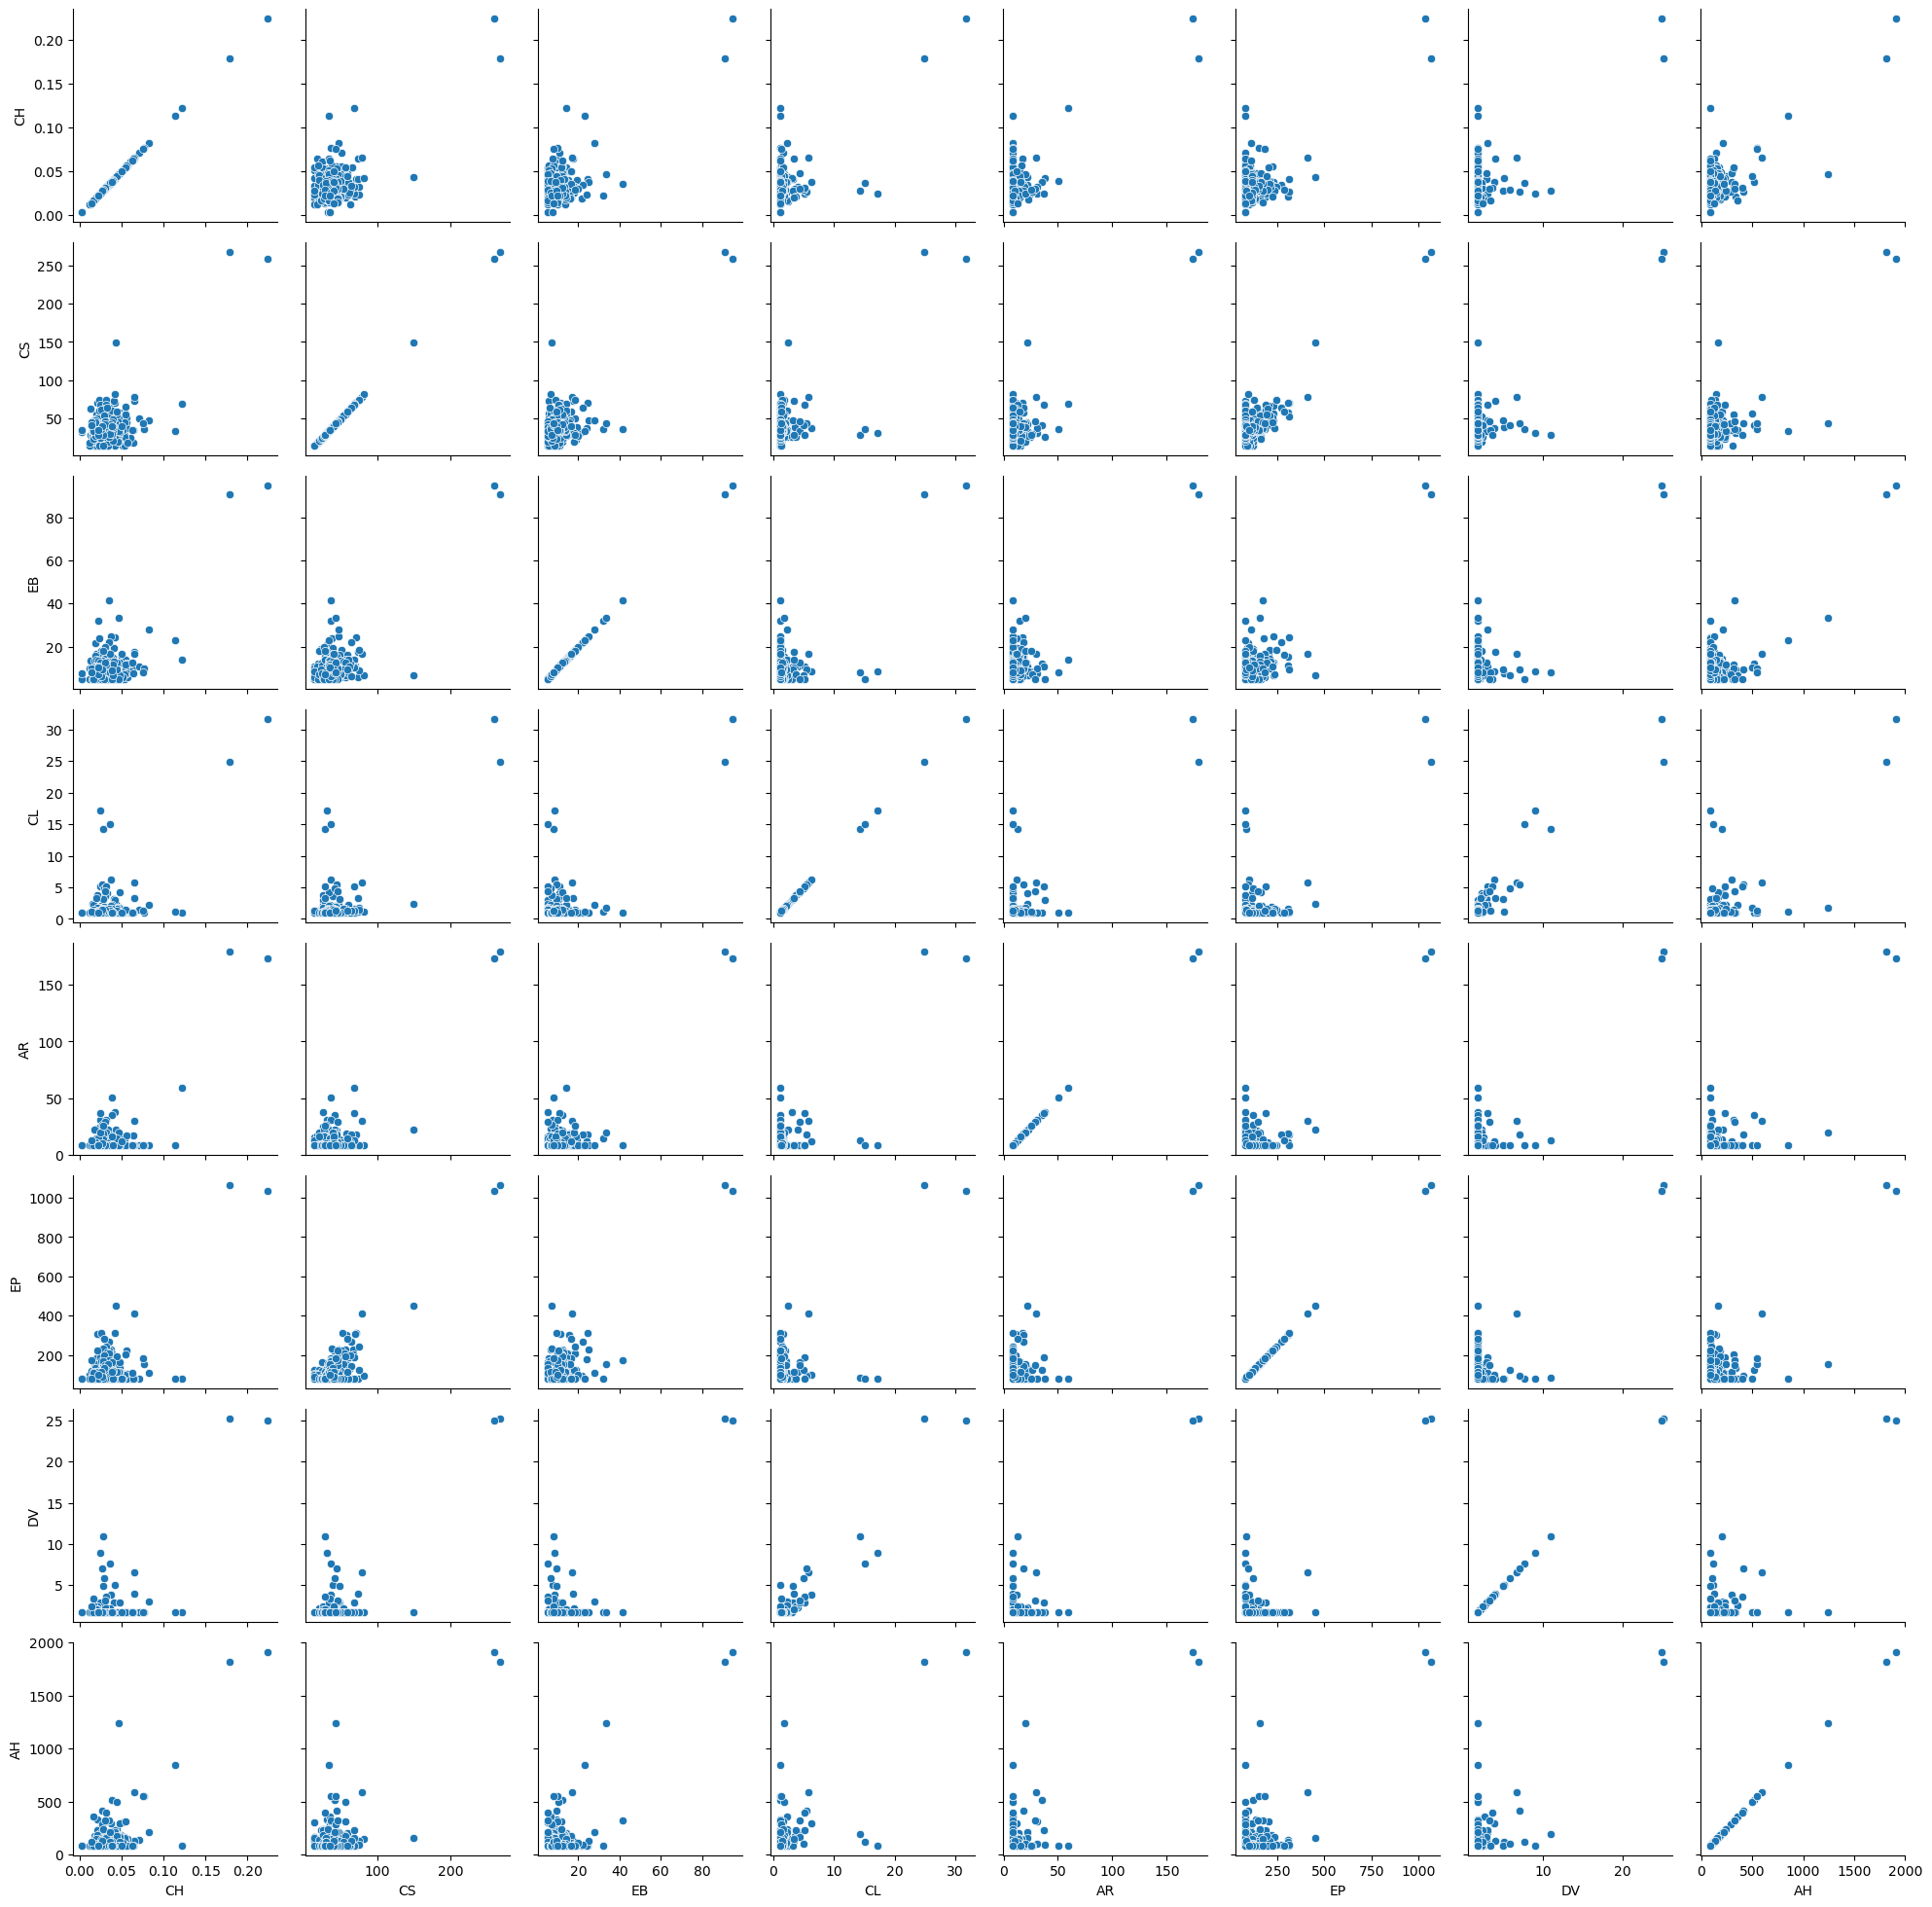

In [14]:
cluster1 = train2[["CH","CS","EB","CL","AR","EP","DV","AH"]]
g = sns.PairGrid(cluster1)
g.map(sns.scatterplot)

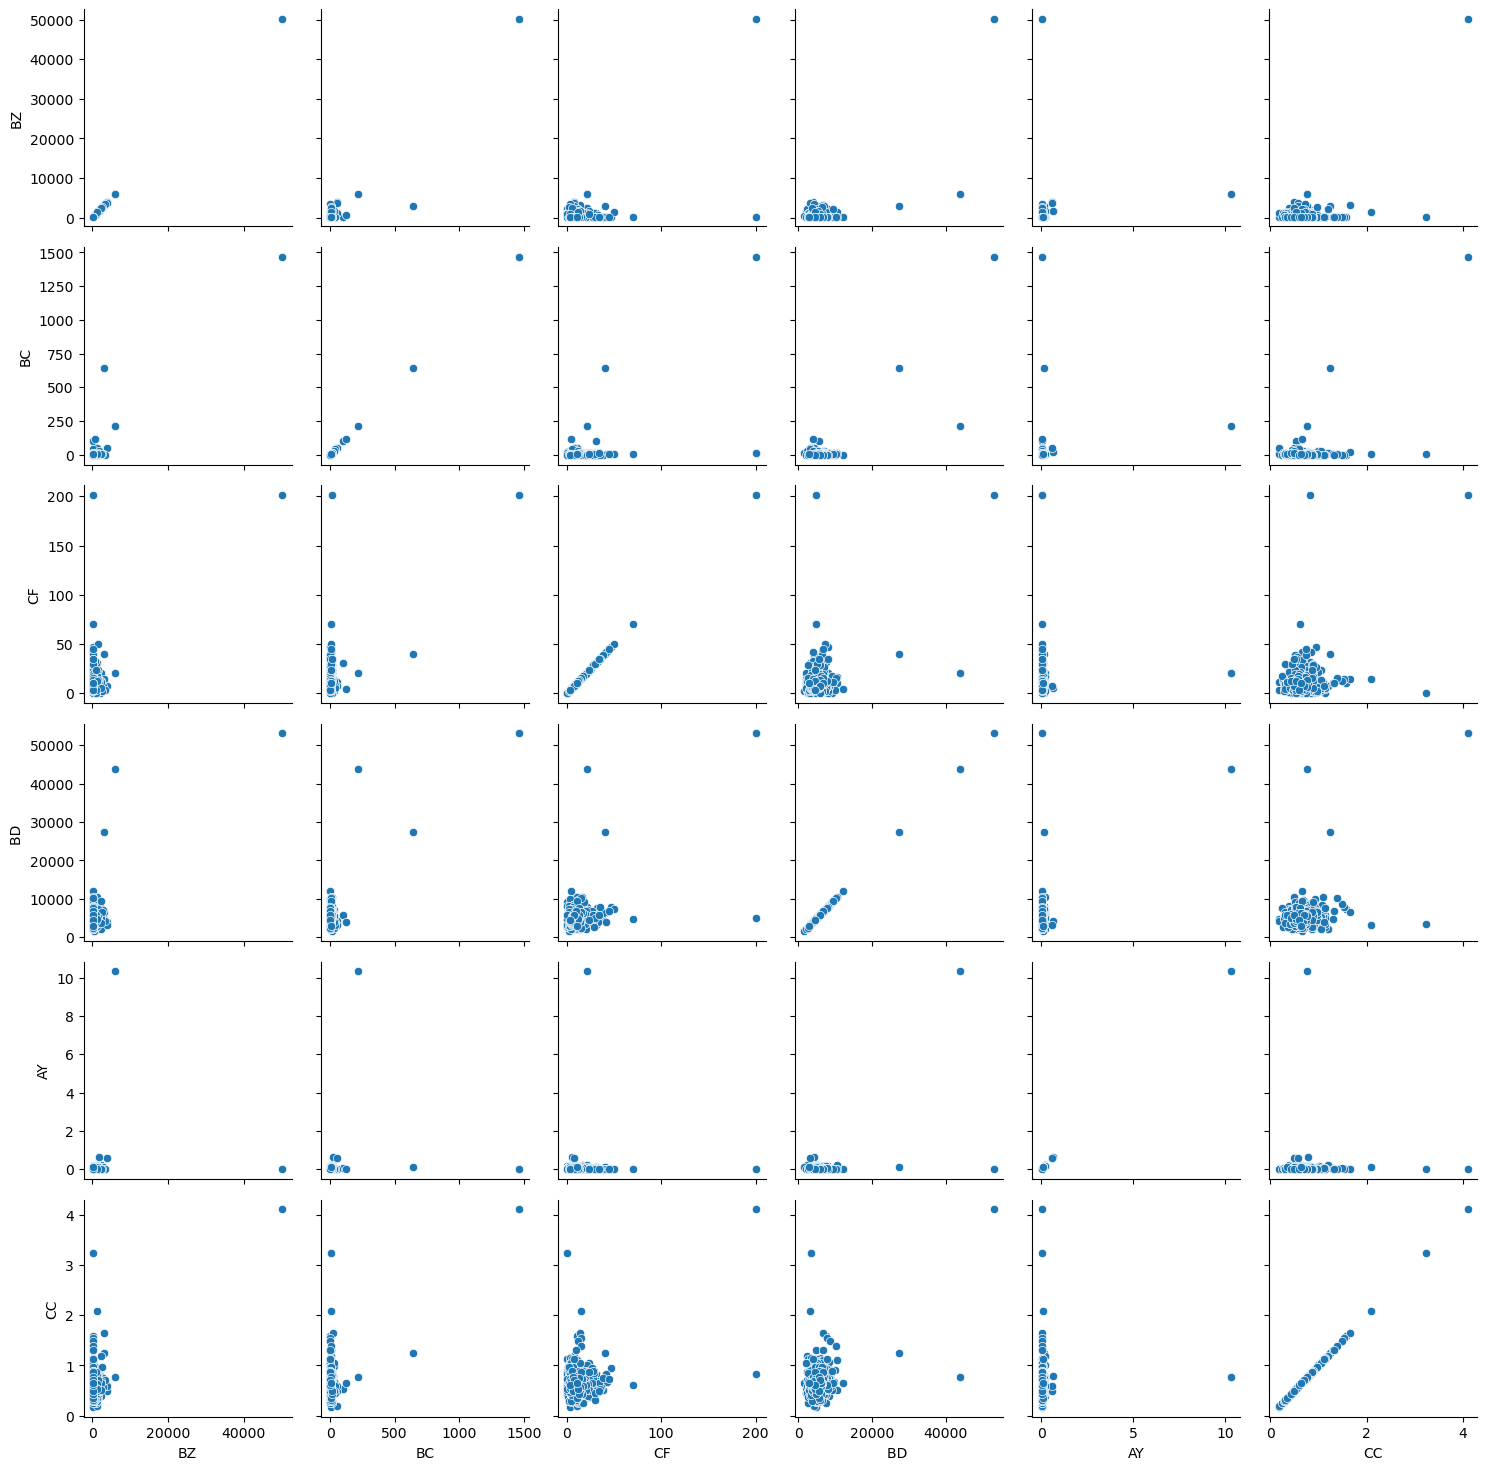

In [15]:
cluster2 = train2[["BZ","BC","CF","BD ","AY","CC"]]
g = sns.PairGrid(cluster2)
g.map(sns.scatterplot)

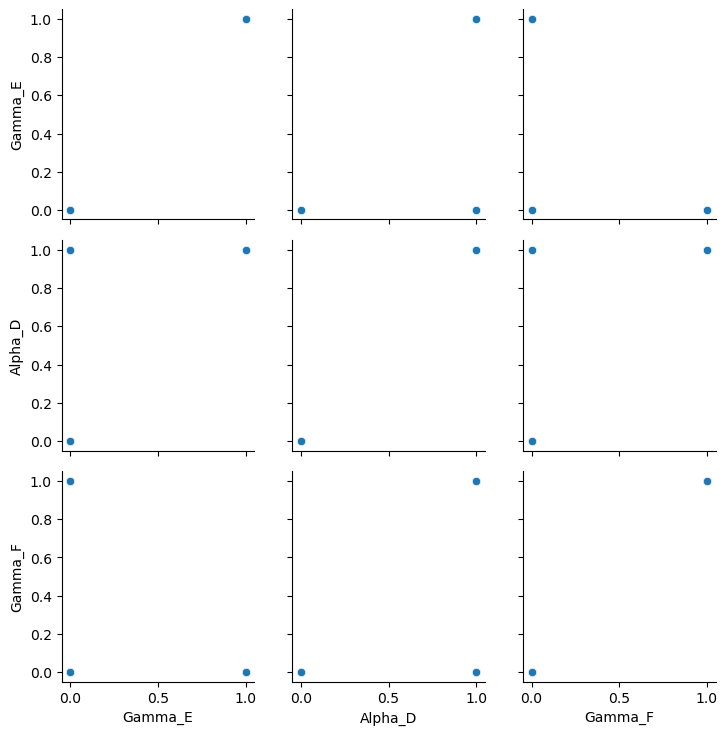

In [16]:
cluster3 = train2[["Gamma_E","Alpha_D","Gamma_F"]]
g = sns.PairGrid(cluster3)
g.map(sns.scatterplot)

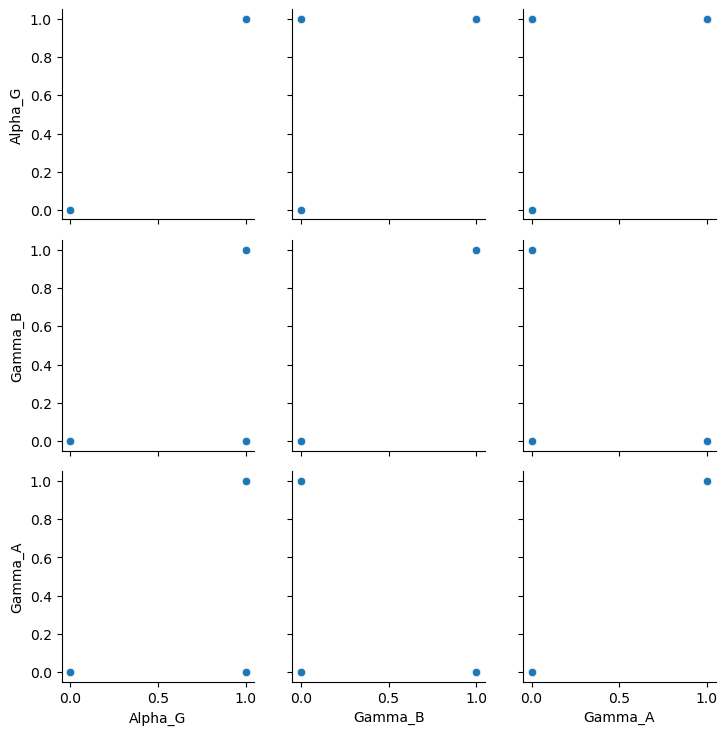

In [17]:
cluster4 = train2[["Alpha_G","Gamma_B","Gamma_A"]]
g = sns.PairGrid(cluster4)
g.map(sns.scatterplot)

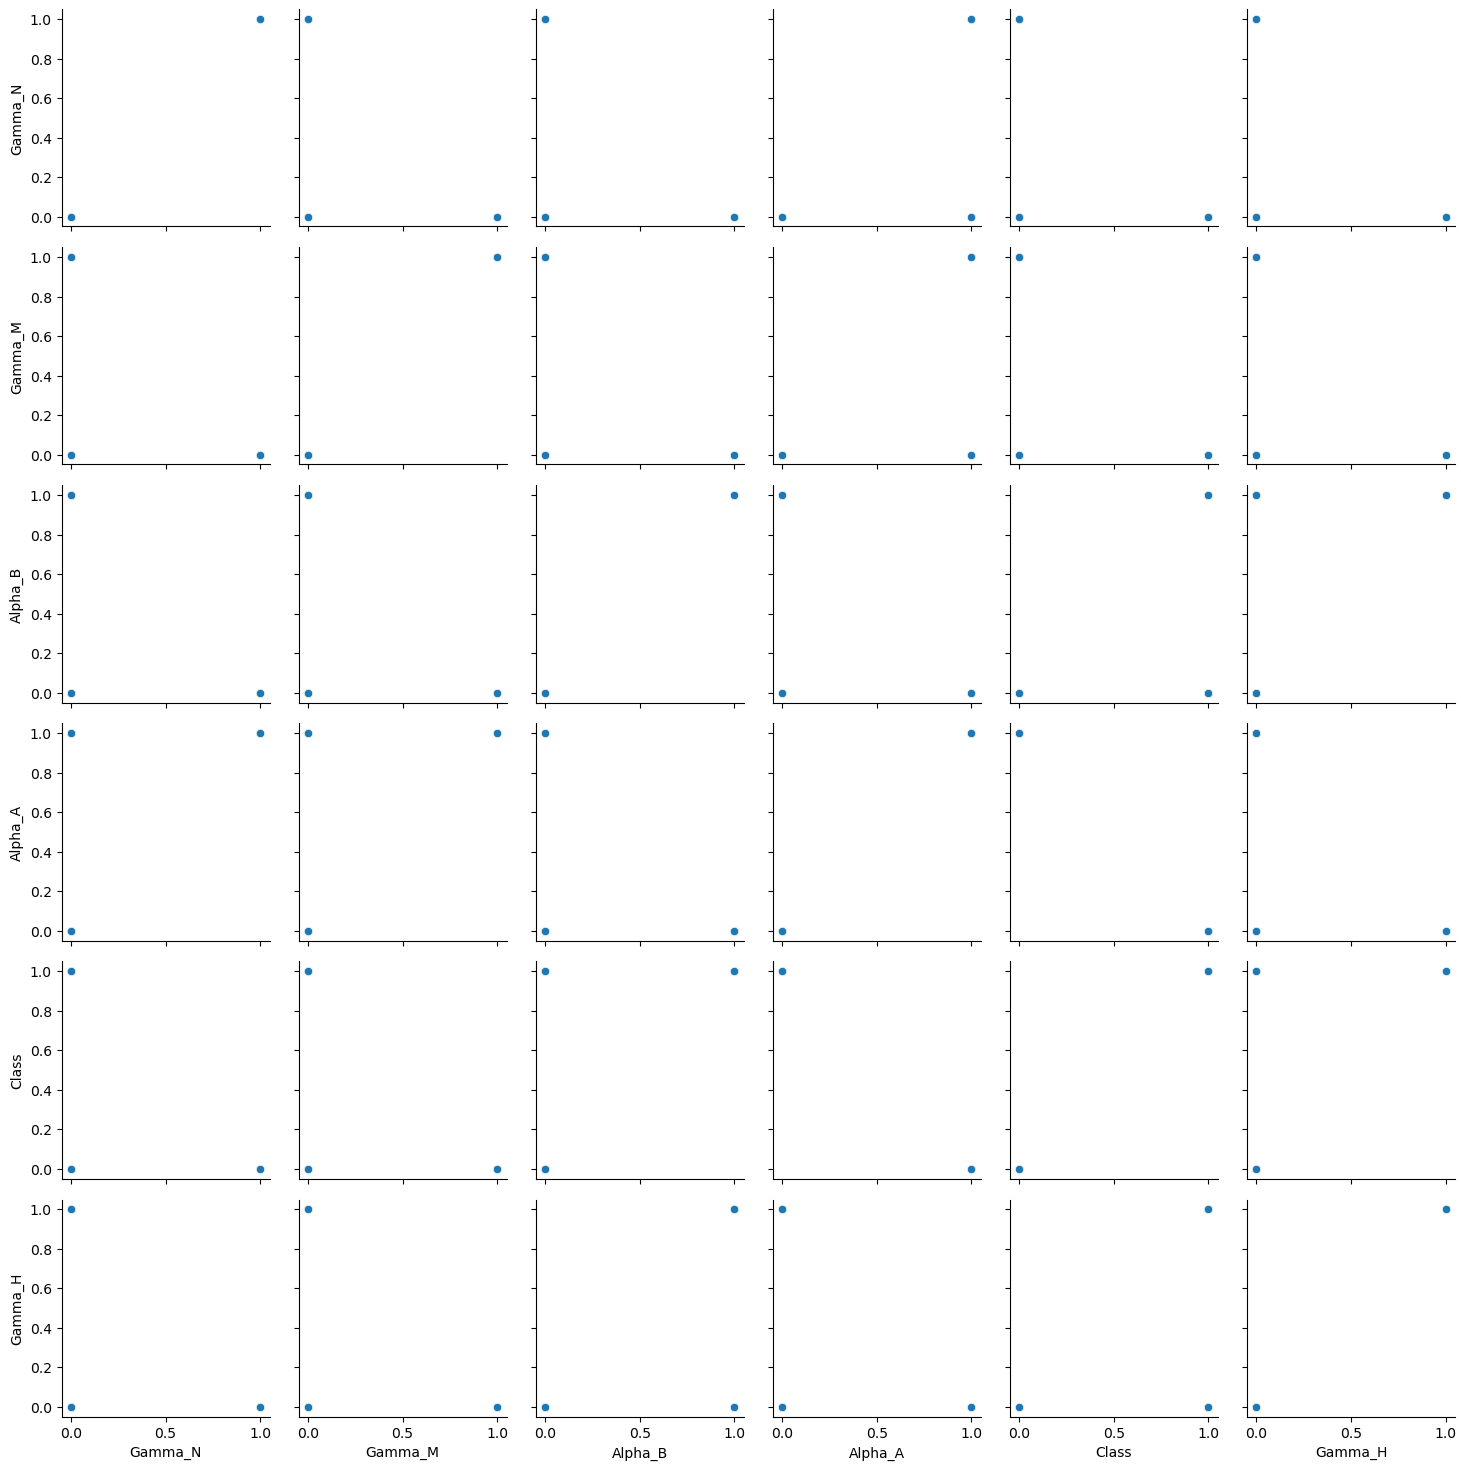

In [18]:
cluster5 = train2[["Gamma_N","Gamma_M","Alpha_B","Alpha_A","Class","Gamma_H"]]
g = sns.PairGrid(cluster5)
g.map(sns.scatterplot)

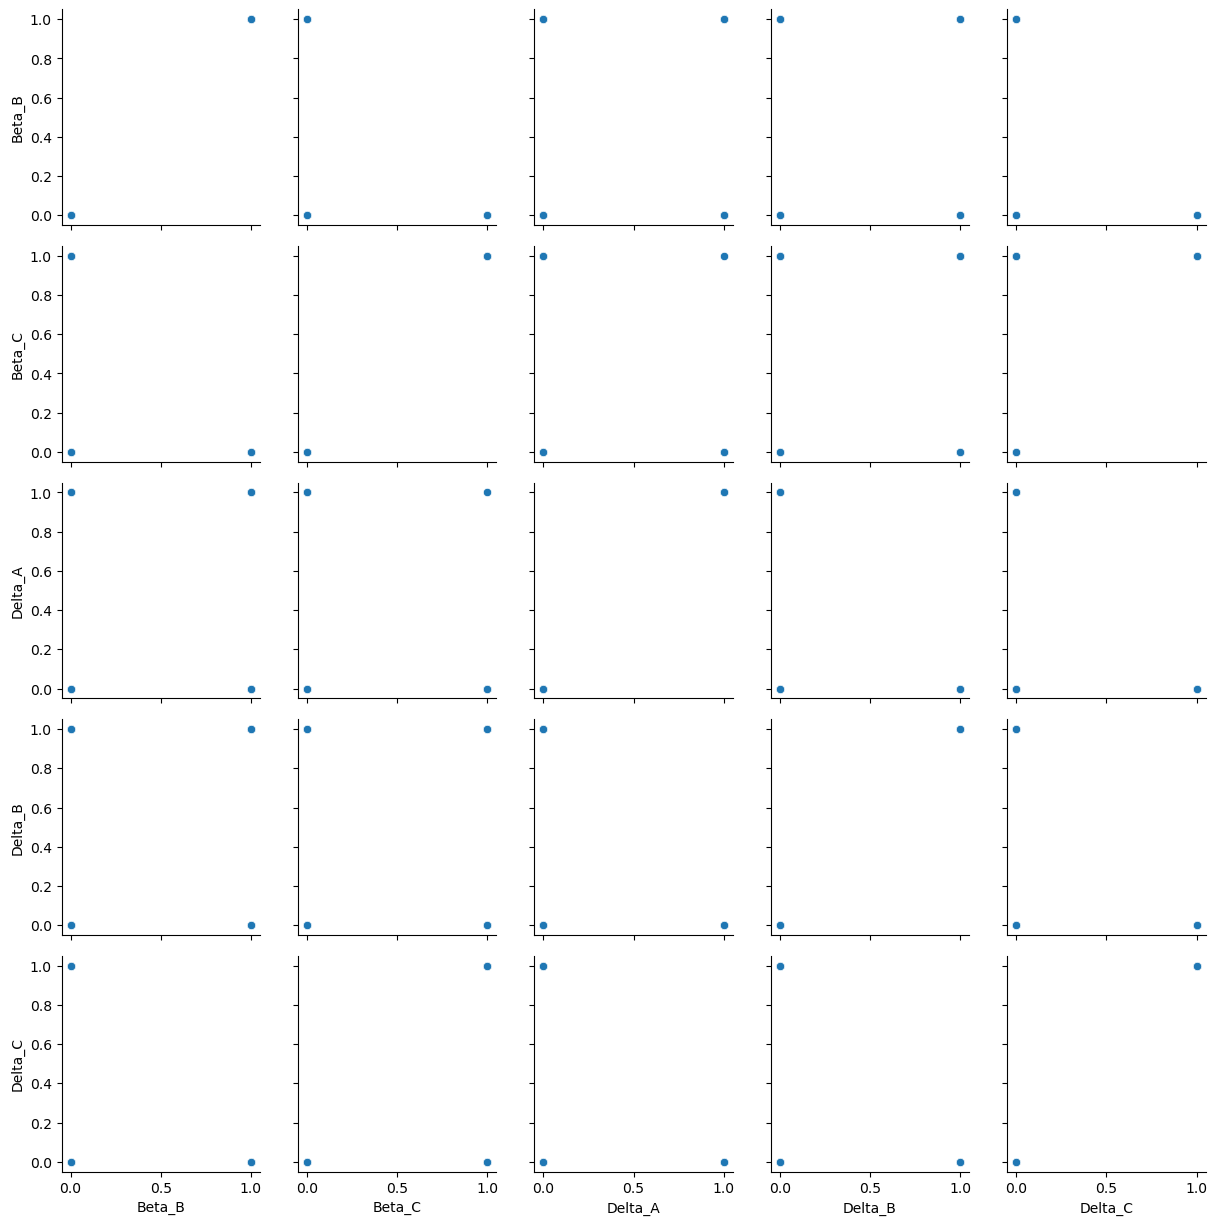

In [19]:
cluster6 = train2[["Beta_B","Beta_C","Delta_A","Delta_B","Delta_C"]]
g = sns.PairGrid(cluster6)
g.map(sns.scatterplot)

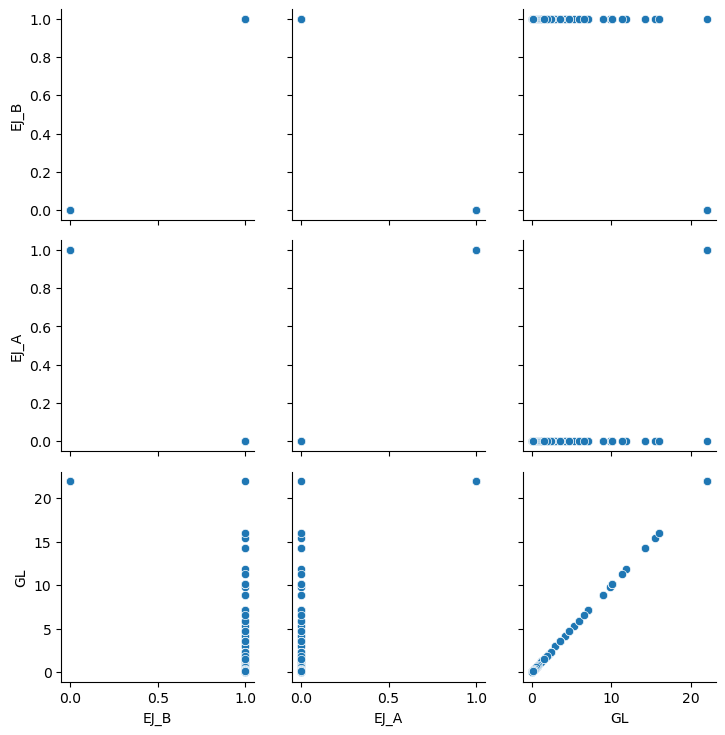

In [20]:
cluster7 = train2[["EJ_B","EJ_A","GL"]]
g = sns.PairGrid(cluster7)
g.map(sns.scatterplot)

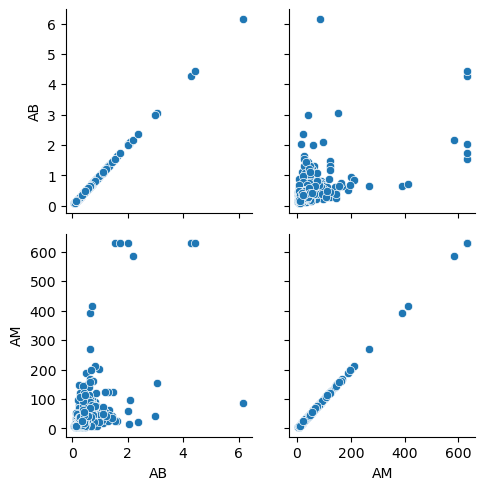

In [21]:
cluster8 = train2[["AB","AM"]]
g = sns.PairGrid(cluster8)
g.map(sns.scatterplot)


Insights Noted:
* None of the features from greeks.csv have any high correlation with the features in train.csv

* Interesting to note that our target variable class (Feature ID 55 in the graph above) is highly  correlated with a few of the greeks.csv features: Gamma_M, Alpha_B, Alpha_A, and Gamma_H

* All highly correlated continuous variables seem to be positively correlated

* Looking at the pair grids, most of the continuous variables have outliers. It would be interesting to see if an outlier value is more likely to give a class=1 value.



# Mutual Information

In [22]:
y_train = train['Class']
train = train.drop("Class",axis=1)
train=train.fillna(0)

In [23]:
discrete_features = train.dtypes == int

In [24]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(train, y_train,discrete_features)

In [25]:
mi_scores

FL      0.111198
GL      0.094228
DU      0.081392
BQ      0.077560
DI      0.055788
AF      0.050577
CC      0.049731
DA      0.048260
AH      0.042119
DF      0.038860
GH      0.034352
EH      0.034177
FR      0.033170
AM      0.033069
CW      0.032716
CR      0.032022
AB      0.030372
EE      0.027648
FE      0.026577
AY      0.025554
GF      0.024886
DE      0.024545
FC      0.023770
FD      0.023715
DH      0.020383
BP      0.019774
BZ      0.018729
BN      0.018642
AX      0.018594
EB      0.016700
FI      0.015266
CD      0.014966
CF      0.014928
BC      0.012452
GE      0.009063
AR      0.008573
EL      0.007044
GI      0.005656
CS      0.001892
DY      0.001077
EG      0.000494
DN      0.000175
CU      0.000000
AZ      0.000000
GB      0.000000
EJ_A    0.000000
FS      0.000000
EU      0.000000
BD      0.000000
BR      0.000000
EP      0.000000
CB      0.000000
DV      0.000000
DL      0.000000
CH      0.000000
CL      0.000000
EJ_B    0.000000
Name: MI Scores, dtype: float64

In [26]:
scores = mi_scores[0:20]

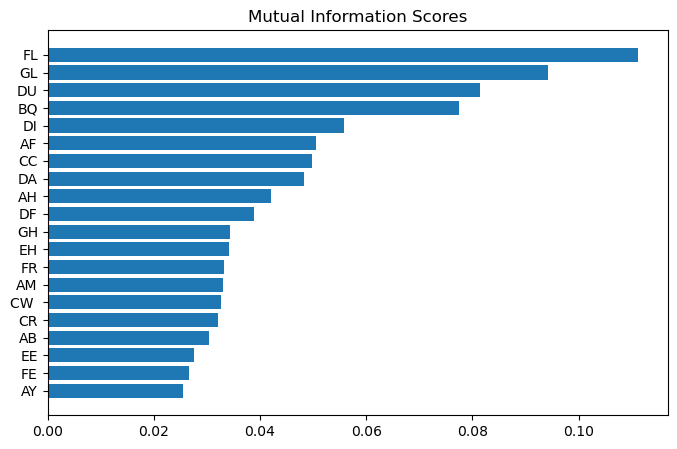

In [27]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(scores)

In [28]:

#It seems that no individual feature by itself provides much information towards
#predicting the target variable. It might be beneficial to look at how informative different
#combination of features are.


# Outlier Analysis

In [29]:
key_features = list(scores.index)

In [30]:
outlier_df = train.copy()
outlier_df['Class'] = y_train

In [31]:
def plot_outliers(key_features,selection):
    
    class_0_mean,class_0_median,class_0_max,class_0_min = [],[],[],[]
    class_1_mean,class_1_median,class_1_max,class_1_min = [],[],[],[]
    for i in range(len(key_features)):
        x=outlier_df[[key_features[i],'Class']]
        class_1_mean.append(x[x['Class'] == 1][key_features[i]].mean())
        class_0_mean.append(x[x['Class'] == 0][key_features[i]].mean())
        class_1_median.append(x[x['Class'] == 1][key_features[i]].median())
        class_0_median.append(x[x['Class'] == 0][key_features[i]].median())
        class_1_max.append(x[x['Class'] == 1][key_features[i]].max())
        class_0_max.append(x[x['Class'] == 0][key_features[i]].max())
        class_1_min.append(x[x['Class'] == 1][key_features[i]].min())
        class_0_min.append(x[x['Class'] == 0][key_features[i]].min())
        
    if selection == "Mean":
        class_0 = class_0_mean
        class_1 = class_1_mean
    elif selection == "Median":
        class_0 = class_0_median
        class_1 = class_1_median
    elif selection == "Max":
        class_0 = class_0_max
        class_1 = class_1_max
    elif selection == "Min":
        class_0 = class_0_min
        class_1 = class_1_min
    
    features = tuple(key_features)
    feature_means = {
        f'Class_0 {selection}': tuple(class_0),
        f'Class_1 {selection}': tuple(class_1),
    }

    x = np.arange(len(features))  # the label locations
    width = 0.25  # the width of the bars
    multiplier = 0
    fig, ax = plt.subplots(layout='constrained')

    for attribute, measurement in feature_means.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        #ax.bar_label(rects, padding=15)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel(f'{selection}')
    ax.set_title(f'Feature {selection}s By Class Value')
    ax.set_xticks(x + width, features)
    ax.legend(loc='upper left', ncols=3)

    #ax.set_ylim(0, )

    plt.show()

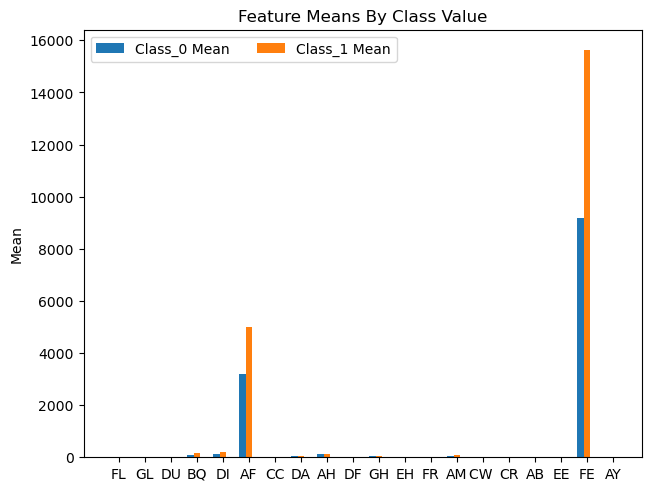

In [32]:
plot_outliers(key_features,"Mean")

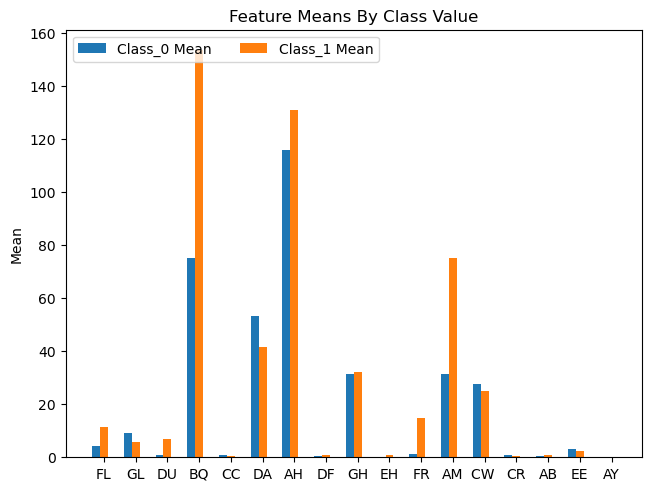

In [33]:
kf2 = key_features.copy()

kf_mean,kf_median,kf_max,kf_min = defaultdict(list), defaultdict(list),defaultdict(list),defaultdict(list)

for i in range(len(key_features)):
    x=outlier_df[[key_features[i],'Class']]
    kf_mean[key_features[i]].append(x[x['Class'] == 1][key_features[i]].mean())
    kf_median[key_features[i]].append(x[x['Class'] == 1][key_features[i]].median())
    kf_max[key_features[i]].append(x[x['Class'] == 1][key_features[i]].max())
    kf_min[key_features[i]].append(x[x['Class'] == 0][key_features[i]].min())
    
max_means = nlargest(3, kf_mean, key = kf_mean.get)
max_medians = nlargest(3, kf_median, key = kf_median.get)
max_maxes = nlargest(3, kf_max, key = kf_max.get)
max_mins = nlargest(3, kf_min, key = kf_min.get)

kf2_mean = [e for e in key_features if e not in max_means]
kf2_median = [e for e in key_features if e not in max_medians]
kf2_max = [e for e in key_features if e not in max_maxes]
kf2_min = [e for e in key_features if e not in max_mins]
    
plot_outliers(kf2_mean,"Mean")

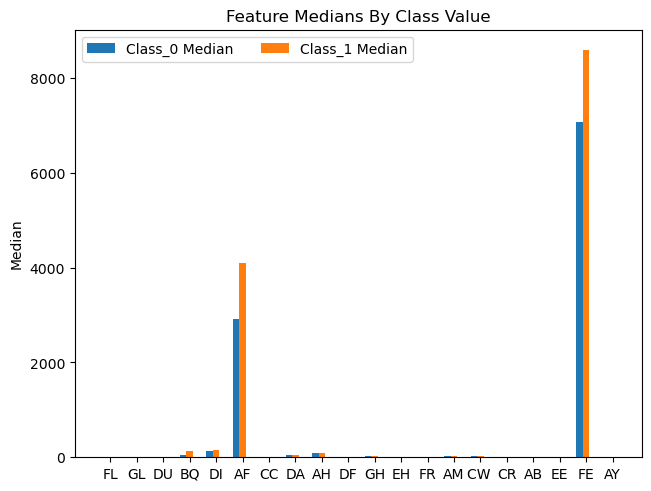

In [34]:
plot_outliers(key_features,"Median")

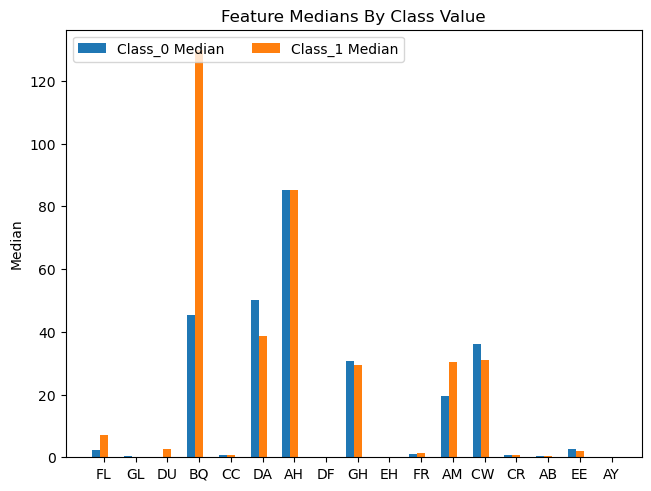

In [35]:
plot_outliers(kf2_median,"Median")

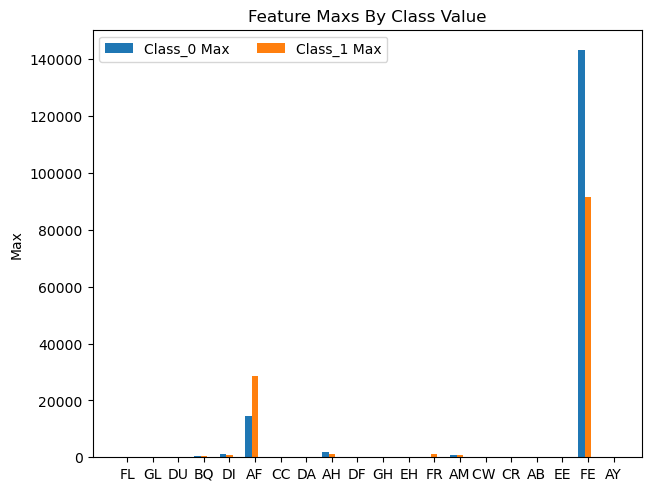

In [36]:
plot_outliers(key_features,"Max")

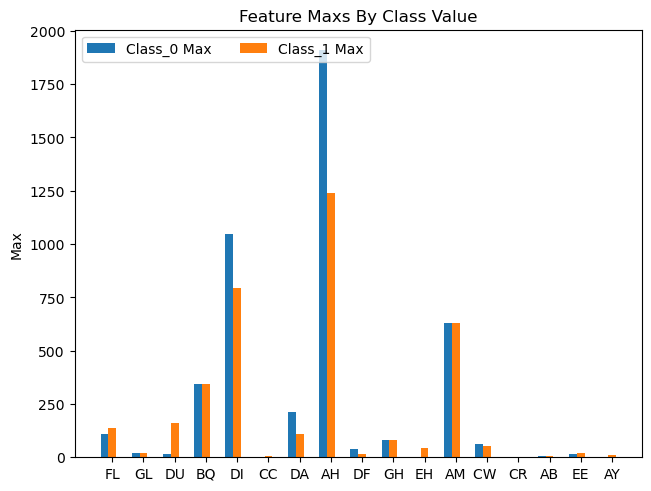

In [37]:
plot_outliers(kf2_max,"Max")

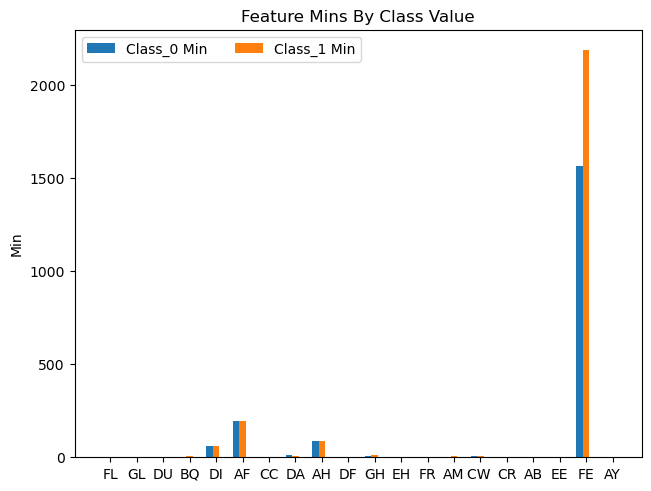

In [38]:
plot_outliers(key_features,"Min")

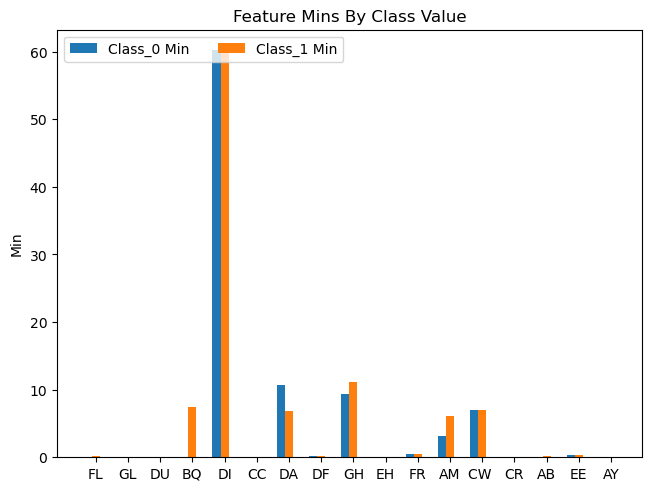

In [39]:
plot_outliers(kf2_min,"Min")